In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb




In [25]:
#Display the first few rows ( to show the features we have )
#pregnancies = times pregnant
#glucose = blood sugar level (mg/dl)
#blood pressure = diastolic blood pressure (mm Hg)
#skin thickness = triceps skin fold thickness (mm)
#insulin = serum insulin (mu U/ml)
#BMI = body mass index (weight in kg/(height in m)^2)
#diabetes pedigree function = function which scores likelihood of diabetes based on family history
#age = age of the patient (years)
#outcome = class variable (0 = non-diabetic or 1 = diabetic) 268 of 768 are 1, the others are 0
df = pd.read_csv('diabetes.csv')

#to see how many people have diabetes and how many do not have diabetes in this dataset
print(df["Outcome"].value_counts())
df.head()

Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Zero values in these columns are invalid (makes no sense medically)
# They will be replaced with NaN and then handled properly
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols_with_zero:
    df[col] = df[col].replace(0, np.nan)
    
# decided filling the NaN values with the median of each column would be the best approach.
# This helps to maintain the distribution of the data without introducing bias.
df.fillna(df.median(), inplace=True)

#notice the difference (previously 0 values were replaced )
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [ ]:
#creating feature matrix (X) and target vector (y)
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

#tried the 80/20 rule for splitting data into training and testing sets. Other percentages were tested.
#The 70/30 split proved to produce the most accurate model for this dataset.
#stratify ensures that the proportion of classes is maintained in both training and testing sets.
#used random_state because it helps to get the same 70/30 split every time the code is run.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=17, stratify=y
)

# Standardize the data: transforms each feature to have mean=0 and std=1.
# Important for models that use distance or gradients (SVM, KNN, Logistic Regression).
# Tree-based models (Random Forest, XGBoost) don't need scaling, but others do.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Logistic Regression
#limited the maximum number of iterations to 1000 to ensure convergence at minimum cost.
#Convergence means the algorithm has found the best parameters to minimize the cost function.
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [6]:
#Random Forest
#three hundred decision trees that answer random questions are created.
#the final prediction is made by the majority vote of all trees.
#in case of ties, the class with the highest average probability is chosen. we can an odd number to make it impossible.
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
#SVM
#A kernel tells the SVM how to measure similarity between points so it can find a non-linear decision boundary.
#In this case, the RBF kernel allows for non-linear separation.
svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train_scaled, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [8]:
#KNN
#classifies a point based on the majority class among its 7 nearest neighbors.
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)


,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [23]:
#XGBoost
#
xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    scale_pos_weight=1.86,
)
xgb_model.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [24]:
#Evaluation
models = {
    "Logistic Regression": logreg,
    "Random Forest": rf,
    "SVM (RBF)": svm,
    "KNN": knn,
    "XGBoost": xgb_model
}

for name, model in models.items():
    if name in ["Random Forest", "XGBoost"]:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    print("====", name, "====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_prob))
    print(classification_report(y_test, y_pred))


==== Logistic Regression ====
Accuracy: 0.7662337662337663
ROC AUC: 0.851440329218107
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       150
           1       0.68      0.62      0.65        81

    accuracy                           0.77       231
   macro avg       0.74      0.73      0.74       231
weighted avg       0.76      0.77      0.76       231

==== Random Forest ====
Accuracy: 0.7792207792207793
ROC AUC: 0.8269958847736626
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       150
           1       0.69      0.67      0.68        81

    accuracy                           0.78       231
   macro avg       0.76      0.75      0.76       231
weighted avg       0.78      0.78      0.78       231

==== SVM (RBF) ====
Accuracy: 0.7532467532467533
ROC AUC: 0.840411522633745
              precision    recall  f1-score   support

           0       0.80      0.83      0.81     

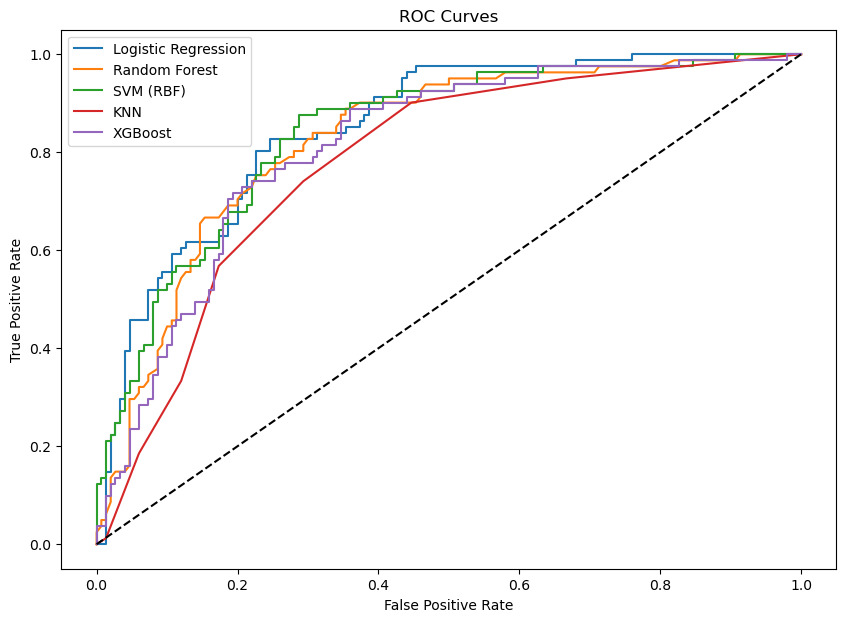

In [12]:
plt.figure(figsize=(10, 7))

for name, model in models.items():
    if name in ["Random Forest", "XGBoost"]:
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


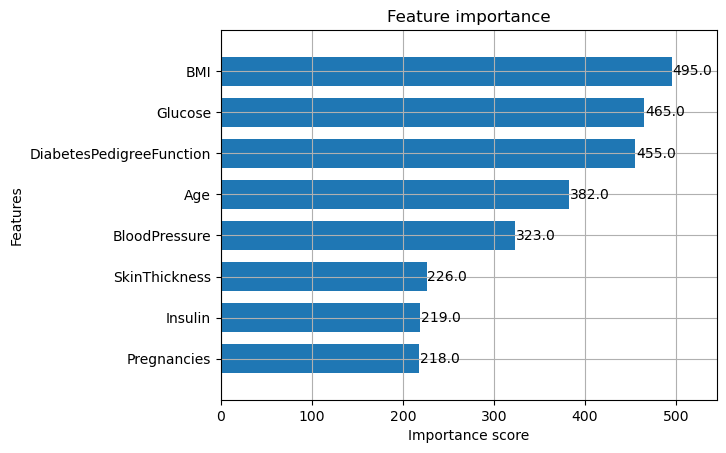

In [13]:
#Feature importance for XGBoost
xgb.plot_importance(xgb_model, height=0.7)
plt.show()

In [14]:
# Likely diabetic case: high glucose, BMI, and diabetes pedigree
new_data = np.array([[8, 180, 80, 35, 130, 35.0, 0.75, 40]])  # 8 months pregnant, high risk factors

# Non-diabetic example
new_data2 = np.array([[1, 85, 66, 29, 0, 26.6, 0.35, 31]])  # low glucose, healthy BMI

# Borderline
new_data3 = np.array([[3, 120, 70, 30, 0, 28.5, 0.40, 45]])  # moderate values


new_data_pred = xgb_model.predict(new_data)
new_data2_pred = xgb_model.predict(new_data2)
new_data3_pred = xgb_model.predict(new_data3)

# Print results
print("Prediction for new data :")
print("Diabetic" if new_data_pred[0] == 1 else "Non-Diabetic")
print("Prediction for new data 2 :")
print("Diabetic" if new_data2_pred[0] == 1 else "Non-Diabetic")
print("Prediction for new data 3 :")
print("Diabetic" if new_data3_pred[0] == 1 else "Non-Diabetic")


Prediction for new data :
Diabetic
Prediction for new data 2 :
Non-Diabetic
Prediction for new data 3 :
Non-Diabetic
